<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & MLflow (Dagshub)

In [1]:
!pip install -q mlflow dagshub
!pip install -q --upgrade statsmodels

import os, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from google.colab import userdata

warnings.filterwarnings('ignore')

os.environ['MLFLOW_TRACKING_USERNAME'] = 'adzid23'
os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('DAGSHUB_TOKEN')

mlflow.set_tracking_uri('https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow')
mlflow.set_experiment('ARIMA_Training')
print('MLflow connected:', mlflow.get_tracking_uri())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/

## 2. Data

In [2]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting -q

os.makedirs('walmart_data', exist_ok=True)
with zipfile.ZipFile('walmart-recruiting-store-sales-forecasting.zip') as z:
    z.extractall('walmart_data')
for f in os.listdir('walmart_data'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(f'walmart_data/{f}') as z:
            z.extractall('walmart_data')

train = pd.read_csv('walmart_data/train.csv', parse_dates=['Date'])
test = pd.read_csv('walmart_data/test.csv',  parse_dates=['Date'])
print(train.shape, test.shape)
print('Train:', train['Date'].min().date(), '→', train['Date'].max().date())
print('Test :', test['Date'].min().date(),  '→', test['Date'].max().date())

(421570, 5) (115064, 4)
Train: 2010-02-05 → 2012-10-26
Test : 2012-11-02 → 2013-07-26


In [3]:
# Each (Store, Dept) becomes one weekly time series with a complete weekly index.
# Missing weeks are filled with 0 — in this dataset a missing week almost always
# means the department recorded no sales, and ARIMA requires evenly spaced data.

full_index = pd.date_range(train['Date'].min(), train['Date'].max(), freq='W-FRI')

def make_series(g):
    s = g.set_index('Date')['Weekly_Sales'].reindex(full_index).fillna(0.0)
    return s

series = {key: make_series(g) for key, g in train.groupby(['Store', 'Dept'])}

lengths = train.groupby(['Store', 'Dept']).size()
print('Series total          :', len(series))
print('Full-length (143 wks) :', (lengths == 143).sum())
print('Short (<104 weeks)    :', (lengths < 104).sum())
print('Very short (<52 weeks):', (lengths < 52).sum())

Series total          : 3331
Full-length (143 wks) : 2660
Short (<104 weeks)    : 463
Very short (<52 weeks): 340


## 3. Validation split & WMAE

In [4]:
VAL_WEEKS = 13
val_start = full_index[-VAL_WEEKS]

holiday_map = train.drop_duplicates('Date').set_index('Date')['IsHoliday']
holiday_map = holiday_map.reindex(full_index).fillna(False)

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5.0, 1.0)
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

train_end_idx = len(full_index) - VAL_WEEKS
print('Fit on   :', full_index[0].date(), '→', full_index[train_end_idx-1].date())
print('Validate :', val_start.date(), '→', full_index[-1].date())
print('Holidays in validation window:', holiday_map[val_start:].sum())

Fit on   : 2010-02-05 → 2012-07-27
Validate : 2012-08-03 → 2012-10-26
Holidays in validation window: 1


In [ ]:
with mlflow.start_run(run_name='ARIMA_Data_Preparation'):
    mlflow.log_params({
        'n_series': len(series),
        'freq': 'W-FRI',
        'reindex_fill': 'zero',
        'val_weeks': VAL_WEEKS,
        'val_start': str(val_start.date()),
        'metric': 'WMAE (holiday weight = 5)',
    })
    mlflow.log_metrics({
        'series_full_length': int((lengths == 143).sum()),
        'series_under_104w': int((lengths < 104).sum()),
        'series_under_52w': int((lengths < 52).sum()),
    })

🏃 View run ARIMA_Data_Preparation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/b24f01bdf2b5440283360e9b7c0f37e5
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0


## 4. Stationarity check - ADF test

In [5]:
from statsmodels.tsa.stattools import adfuller

rng = np.random.default_rng(42)
full_keys = [k for k in series if lengths.get(k, 0) == 143]
sample_keys = rng.choice(len(full_keys), size=100, replace=False)
sample_keys = [full_keys[i] for i in sample_keys]

def adf_pvalue(s):
    try:
        return adfuller(s.dropna(), autolag='AIC')[1]
    except Exception:
        return np.nan

p_level = np.array([adf_pvalue(series[k][:val_start][:-1]) for k in sample_keys])
p_diff1 = np.array([adf_pvalue(series[k][:val_start][:-1].diff()) for k in sample_keys])

pct_level = np.nanmean(p_level < 0.05) * 100
pct_diff1 = np.nanmean(p_diff1 < 0.05) * 100
print(f'Stationary at level (d=0): {pct_level:.0f}% of sampled series')
print(f'Stationary after diff (d=1): {pct_diff1:.0f}%')

Stationary at level (d=0): 79% of sampled series
Stationary after diff (d=1): 99%


🏃 View run ARIMA_Stationarity_Check at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/43b162472e0348d3b72eb926883a4ad4
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0


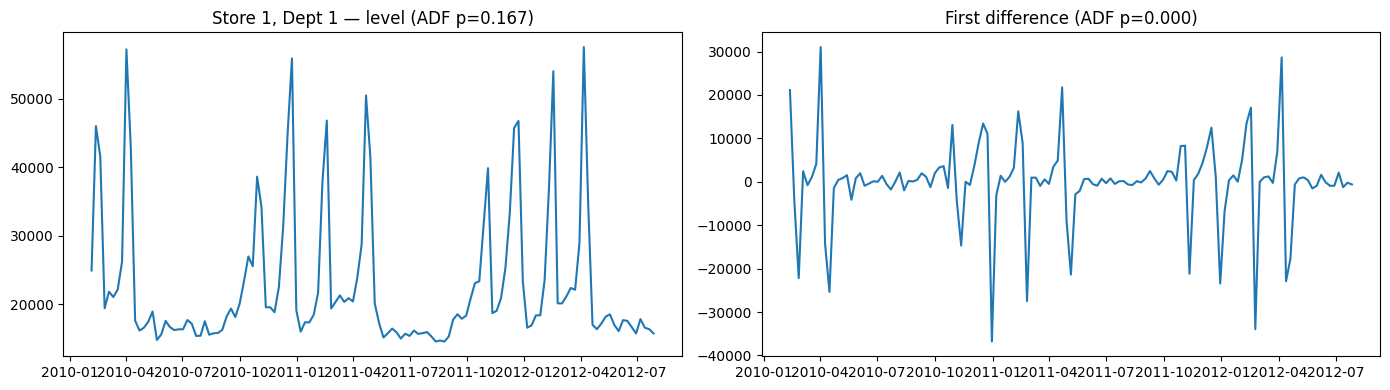

In [ ]:
example = series[(1, 1)][:val_start][:-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(example); axes[0].set_title(f'Store 1, Dept 1 — level (ADF p={adf_pvalue(example):.3f})')
axes[1].plot(example.diff()); axes[1].set_title(f'First difference (ADF p={adf_pvalue(example.diff()):.3f})')
plt.tight_layout()

with mlflow.start_run(run_name='ARIMA_Stationarity_Check'):
    mlflow.log_params({'test': 'ADF', 'sample_size': 100, 'alpha': 0.05})
    mlflow.log_metrics({'pct_stationary_d0': pct_level,
                        'pct_stationary_d1': pct_diff1})
    mlflow.log_figure(fig, 'stationarity_store1_dept1.png')
plt.show()

## 5. ACF / PACF

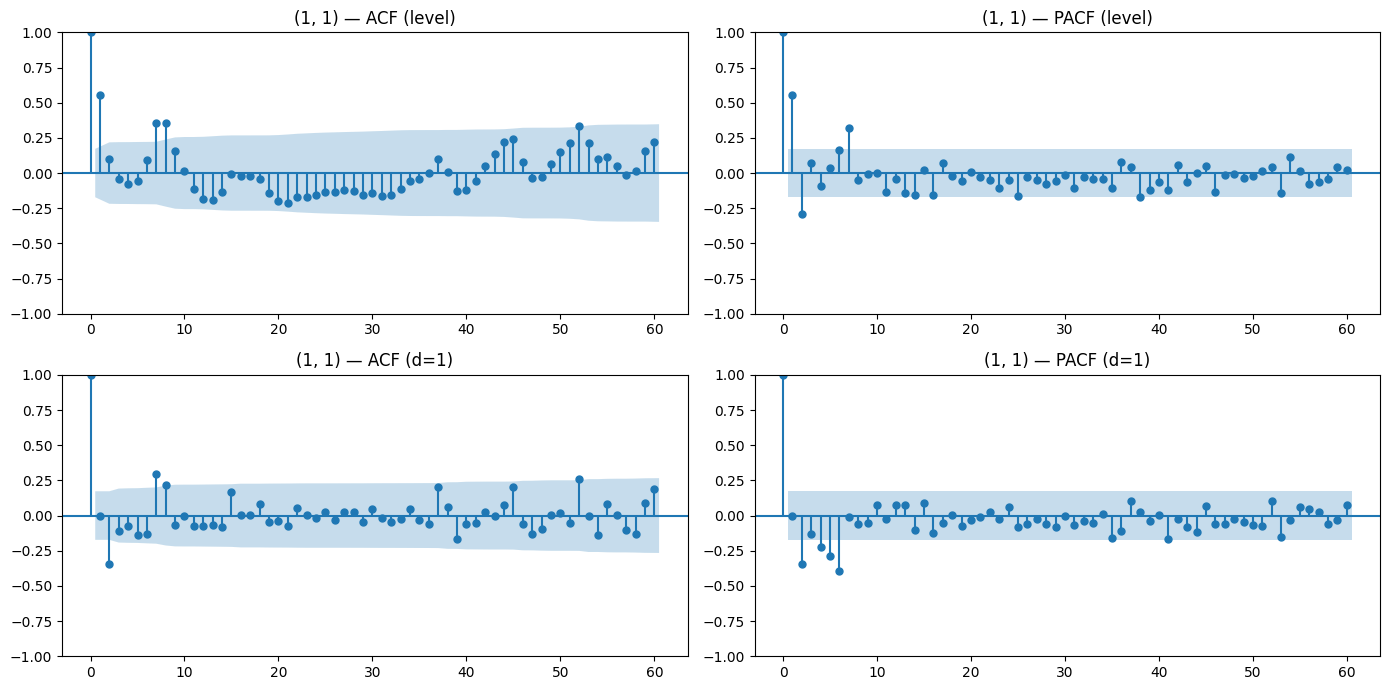

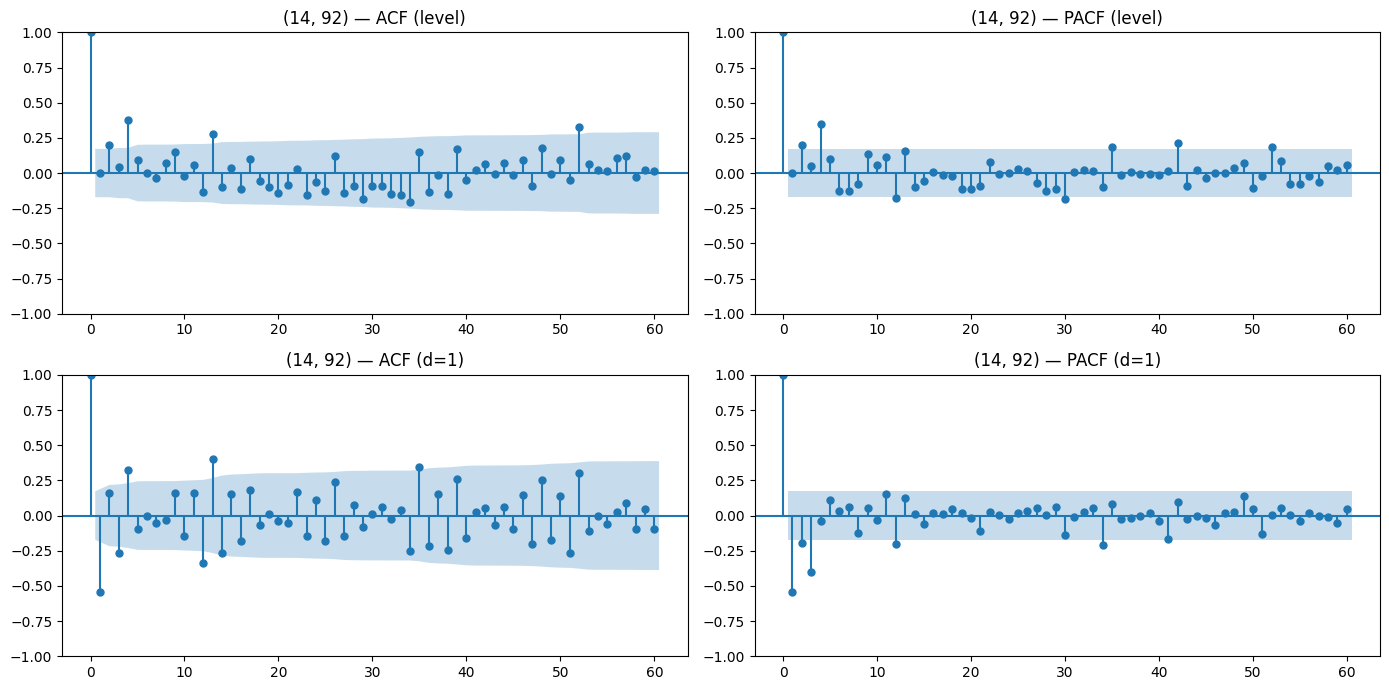

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

mean_sales = train.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()

def acf_pacf_fig(key):
  s = series[key][:val_start][:-1]
  d1 = s.diff().dropna()
  fig, axes = plt.subplots(2, 2, figsize=(14, 7))
  plot_acf(s,   lags=60, ax=axes[0, 0], title=f'({key[0]}, {key[1]}) — ACF (level)')
  plot_pacf(s,  lags=60, ax=axes[0, 1], method='ywm', title=f'({key[0]}, {key[1]}) — PACF (level)')
  plot_acf(d1,  lags=60, ax=axes[1, 0], title=f'({key[0]}, {key[1]}) — ACF (d=1)')
  plot_pacf(d1, lags=60, ax=axes[1, 1], method='ywm', title=f'({key[0]}, {key[1]}) — PACF (d=1)')
  plt.tight_layout()
  return fig

fig_typical = acf_pacf_fig((1, 1))                      # typical series
top_key = mean_sales.idxmax()                           # highest-volume series
fig_top = acf_pacf_fig(top_key)
plt.show()

## 6. Order selection

In [7]:
# 15 top-volume series (dominate WMAE) + 15 random full-length series (unbiased view)
full_set = set(full_keys)
top15  = [k for k in mean_sales.sort_values(ascending=False).index if k in full_set][:15]
rng6   = np.random.default_rng(6)
pool   = [k for k in full_keys if k not in set(top15)]
rand15 = [pool[i] for i in rng6.choice(len(pool), size=15, replace=False)]
grid_keys = top15 + rand15
print('Grid series:', len(grid_keys), '| example top:', top15[:3])

Grid series: 30 | example top: [(14, 92), (2, 92), (20, 92)]


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

candidates = {
    'AR':    [(1,0,0), (2,0,0), (3,0,0)],
    'MA':    [(0,0,1), (0,0,2), (0,0,3)],
    'ARMA':  [(1,0,1), (2,0,1), (1,0,2), (2,0,2)],
    'ARIMA': [(0,1,1), (1,1,0), (1,1,1), (2,1,1), (1,1,2), (2,1,2)],
}

w_val = np.where(holiday_map[val_start:].values, 5.0, 1.0)

def eval_order(order):
    aics, abs_err_w, weights = [], 0.0, 0.0
    n_ok = 0
    trend = 'c' if order[1] == 0 else None      # d=0 needs an intercept (series mean != 0)
    for k in grid_keys:
        s  = series[k]
        tr, va = s[:val_start][:-1], s[val_start:]
        try:
            m  = SARIMAX(tr, order=order, trend=trend,
                         enforce_stationarity=False, enforce_invertibility=False
                        ).fit(disp=0)
            fc = np.asarray(m.forecast(VAL_WEEKS))
            aics.append(m.aic)
            abs_err_w += np.sum(w_val * np.abs(va.values - fc))
            weights   += np.sum(w_val)
            n_ok += 1
        except Exception:
            continue
    return np.mean(aics), abs_err_w / weights, n_ok

rows = []
for family, orders in candidates.items():
    for order in orders:
        mean_aic, val_wmae, n_ok = eval_order(order)
        rows.append({'family': family, 'order': str(order),
                     'mean_AIC': round(mean_aic, 1),
                     'val_WMAE': round(val_wmae, 1), 'n_ok': n_ok})
        print(rows[-1])

grid_df = pd.DataFrame(rows)
display(grid_df.sort_values(['family', 'val_WMAE']))

{'family': 'AR', 'order': '(1, 0, 0)', 'mean_AIC': np.float64(2556.8), 'val_WMAE': np.float64(8515.4), 'n_ok': 30}
{'family': 'AR', 'order': '(2, 0, 0)', 'mean_AIC': np.float64(2533.1), 'val_WMAE': np.float64(7737.3), 'n_ok': 30}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'family': 'AR', 'order': '(3, 0, 0)', 'mean_AIC': np.float64(2512.4), 'val_WMAE': np.float64(7258.8), 'n_ok': 30}
{'family': 'MA', 'order': '(0, 0, 1)', 'mean_AIC': np.float64(2551.7), 'val_WMAE': np.float64(8706.3), 'n_ok': 30}
{'family': 'MA', 'order': '(0, 0, 2)', 'mean_AIC': np.float64(2523.4), 'val_WMAE': np.float64(8489.4), 'n_ok': 30}
{'family': 'MA', 'order': '(0, 0, 3)', 'mean_AIC': np.float64(2503.6), 'val_WMAE': np.float64(8336.6), 'n_ok': 30}
{'family': 'ARMA', 'order': '(1, 0, 1)', 'mean_AIC': np.float64(2534.0), 'val_WMAE': np.float64(7989.8), 'n_ok': 30}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'family': 'ARMA', 'order': '(2, 0, 1)', 'mean_AIC': np.float64(2537.2), 'val_WMAE': np.float64(7578.1), 'n_ok': 30}
{'family': 'ARMA', 'order': '(1, 0, 2)', 'mean_AIC': np.float64(2514.4), 'val_WMAE': np.float64(7630.1), 'n_ok': 30}
{'family': 'ARMA', 'order': '(2, 0, 2)', 'mean_AIC': np.float64(2514.7), 'val_WMAE': np.float64(7123.6), 'n_ok': 30}
{'family': 'ARIMA', 'order': '(0, 1, 1)', 'mean_AIC': np.float64(2516.7), 'val_WMAE': np.float64(6353.2), 'n_ok': 30}
{'family': 'ARIMA', 'order': '(1, 1, 0)', 'mean_AIC': np.float64(2557.5), 'val_WMAE': np.float64(8015.7), 'n_ok': 30}
{'family': 'ARIMA', 'order': '(1, 1, 1)', 'mean_AIC': np.float64(2515.0), 'val_WMAE': np.float64(6310.0), 'n_ok': 30}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'family': 'ARIMA', 'order': '(2, 1, 1)', 'mean_AIC': np.float64(2512.8), 'val_WMAE': np.float64(6349.5), 'n_ok': 30}
{'family': 'ARIMA', 'order': '(1, 1, 2)', 'mean_AIC': np.float64(2494.1), 'val_WMAE': np.float64(6150.6), 'n_ok': 30}
{'family': 'ARIMA', 'order': '(2, 1, 2)', 'mean_AIC': np.float64(2488.5), 'val_WMAE': np.float64(5926.6), 'n_ok': 30}


,family,order,mean_AIC,val_WMAE,n_ok
2,AR,"(3, 0, 0)",2512.4,7258.8,30
1,AR,"(2, 0, 0)",2533.1,7737.3,30
0,AR,"(1, 0, 0)",2556.8,8515.4,30
15,ARIMA,"(2, 1, 2)",2488.5,5926.6,30
14,ARIMA,"(1, 1, 2)",2494.1,6150.6,30
12,ARIMA,"(1, 1, 1)",2515.0,6310.0,30
13,ARIMA,"(2, 1, 1)",2512.8,6349.5,30
10,ARIMA,"(0, 1, 1)",2516.7,6353.2,30
11,ARIMA,"(1, 1, 0)",2557.5,8015.7,30
9,ARMA,"(2, 0, 2)",2514.7,7123.6,30


In [ ]:
grid_df.to_csv('arima_order_grid.csv', index=False)
best_per_family = grid_df.loc[grid_df.groupby('family')['val_WMAE'].idxmin()]
best_overall = best_per_family.loc[best_per_family['val_WMAE'].idxmin()]

with mlflow.start_run(run_name='ARIMA_Order_Selection'):
    mlflow.log_params({'grid_series': len(grid_keys), 'sampling': '15 top-volume + 15 random',
                       'selection_rule': 'AIC within d, val WMAE across families'})
    for _, r in best_per_family.iterrows():
        mlflow.log_metric(f"wmae_best_{r['family']}", r['val_WMAE'])
    mlflow.log_param('best_order_overall', best_overall['order'])
    mlflow.log_artifact('arima_order_grid.csv')
    mlflow.log_figure(fig_typical, 'acf_pacf_store1_dept1.png')
    mlflow.log_figure(fig_top, f'acf_pacf_top_series.png')

print('Best per family:')
display(best_per_family)
print('Winner:', best_overall['family'], best_overall['order'])

🏃 View run ARIMA_Order_Selection at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/2629e5eb7c9147bbb073a0505b88fec4
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0
Best per family:


,family,order,mean_AIC,val_WMAE,n_ok
2,AR,"(3, 0, 0)",2512.4,7258.8,30
15,ARIMA,"(2, 1, 2)",2488.5,5926.6,30
9,ARMA,"(2, 0, 2)",2514.7,7123.6,30
5,MA,"(0, 0, 3)",2503.6,8336.6,30


Winner: ARIMA (2, 1, 2)


## 7. Baselines - Naive & Seasonal Naive

In [11]:
# Validation set: 300 top-volume + 300 random full-length series
top300 = [k for k in mean_sales.sort_values(ascending=False).index if k in full_set][:300]
pool2  = [k for k in full_keys if k not in set(top300)]
rng7   = np.random.default_rng(7)
rand300 = [pool2[i] for i in rng7.choice(len(pool2), size=300, replace=False)]
VAL_KEYS = top300 + rand300

def baseline_wmae(keys):
    num = {'naive': 0.0, 'snaive': 0.0}; den = 0.0
    for k in keys:
        s  = series[k]
        va = s[val_start:].values
        naive  = np.repeat(s[:val_start][:-1].iloc[-1], VAL_WEEKS)
        snaive = s.shift(52)[val_start:].values          # same week last year
        den += w_val.sum()
        num['naive']  += np.sum(w_val * np.abs(va - naive))
        num['snaive'] += np.sum(w_val * np.abs(va - snaive))
    return {name: v / den for name, v in num.items()}

bl = baseline_wmae(VAL_KEYS)
print(f"Naive WMAE          : {bl['naive']:.1f}")
print(f"Seasonal-Naive WMAE : {bl['snaive']:.1f}")

with mlflow.start_run(run_name='ARIMA_Baseline_Naive'):
    mlflow.set_tags({'stage': 'baseline', 'model_family': 'ARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Naive (last value) and seasonal-naive (t-52) baselines on 600 series '
        '(300 top-volume + 300 random). The bar any ARIMA must clear.')
    mlflow.log_params({'n_series': len(VAL_KEYS), 'sampling': '300 top + 300 random'})
    mlflow.log_metrics({'val_wmae_naive': bl['naive'], 'val_wmae_snaive': bl['snaive']})

Naive WMAE          : 4628.0
Seasonal-Naive WMAE : 3611.4
🏃 View run ARIMA_Baseline_Naive at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/a382076173244d909633236597bb33bc
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0


## 8. ARIMA(2,1,2) full validation

In [12]:
from tqdm.auto import tqdm

BEST_ORDER = (2, 1, 2)

def fit_forecast(key, order):
    tr = series[key][:val_start][:-1]
    try:
        m = SARIMAX(tr, order=order,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=0, maxiter=200)
        fc = np.asarray(m.forecast(VAL_WEEKS))
        if not np.all(np.isfinite(fc)):
            raise ValueError('non-finite forecast')
        return np.maximum(fc, 0.0), True          # sales can't be negative... mostly
    except Exception:
        return np.repeat(max(tr.iloc[-1], 0.0), VAL_WEEKS), False

num_a = den = 0.0
n_fallback = 0
per_series = []
for k in tqdm(VAL_KEYS):
    fc, ok = fit_forecast(k, BEST_ORDER)
    va = series[k][val_start:].values
    e  = np.sum(w_val * np.abs(va - fc))
    num_a += e; den += w_val.sum()
    n_fallback += (not ok)
    per_series.append({'store': k[0], 'dept': k[1],
                       'wmae': e / w_val.sum(), 'fallback': not ok})

arima_wmae = num_a / den
print(f'ARIMA{BEST_ORDER} WMAE : {arima_wmae:.1f}')
print(f'vs naive {bl["naive"]:.1f} | vs seasonal-naive {bl["snaive"]:.1f}')
print(f'Fallbacks: {n_fallback}/{len(VAL_KEYS)}')

  0%|          | 0/600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 1, 2) WMAE : 3879.8
vs naive 4628.0 | vs seasonal-naive 3611.4
Fallbacks: 0/600


🏃 View run ARIMA_Validation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/ffab5e8b9e9c4a51b95ba342f2cd2aa0
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0


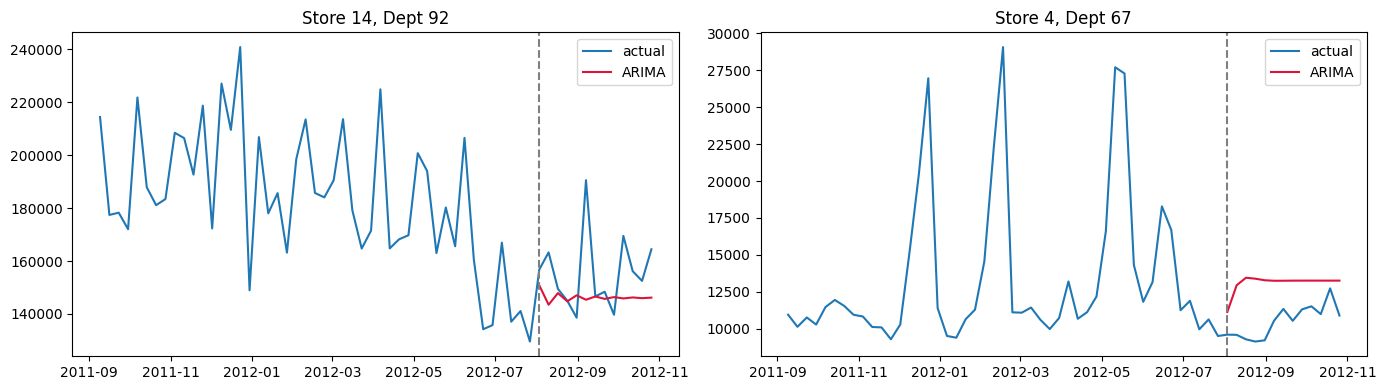

In [13]:
ps = pd.DataFrame(per_series).sort_values('wmae')
ps.to_csv('arima_val_per_series.csv', index=False)

def plot_forecast(key, ax):
    s = series[key]
    fc, _ = fit_forecast(key, BEST_ORDER)
    ax.plot(s[-60:], label='actual')
    ax.plot(s[val_start:].index, fc, label='ARIMA', color='crimson')
    ax.axvline(val_start, ls='--', c='gray')
    ax.set_title(f'Store {key[0]}, Dept {key[1]}'); ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_forecast(top15[0], axes[0])                                  # biggest series
plot_forecast(tuple(ps.iloc[len(ps)//2][['store','dept']]), axes[1])  # median series
plt.tight_layout()

with mlflow.start_run(run_name='ARIMA_Validation'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'ARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        f'ARIMA{BEST_ORDER} fitted per-series on 600 series (300 top + 300 random), '
        f'13-week holdout. Forecasts clipped at 0, naive fallback on fit failure.')
    mlflow.log_params({'order': str(BEST_ORDER), 'n_series': len(VAL_KEYS),
                       'clip_negative': True, 'maxiter': 200})
    mlflow.log_metrics({'val_wmae': arima_wmae,
                        'val_wmae_naive': bl['naive'],
                        'val_wmae_snaive': bl['snaive'],
                        'improvement_vs_naive_pct': 100*(1 - arima_wmae/bl['naive']),
                        'improvement_vs_snaive_pct': 100*(1 - arima_wmae/bl['snaive']),
                        'n_fallback': n_fallback})
    mlflow.log_artifact('arima_val_per_series.csv')
    mlflow.log_figure(fig, 'arima_forecast_examples.png')
plt.show()

## 9. Log-transformation

In [14]:
def fit_forecast_log(key, order):
    tr_raw = series[key][:val_start][:-1]
    try:
        m = SARIMAX(np.log1p(tr_raw), order=order,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=0, maxiter=200)
        fc = np.expm1(np.asarray(m.forecast(VAL_WEEKS)))
        if not np.all(np.isfinite(fc)):
            raise ValueError('non-finite forecast')
        return np.maximum(fc, 0.0), True
    except Exception:
        return np.repeat(max(tr_raw.iloc[-1], 0.0), VAL_WEEKS), False

num_l = 0.0; den_l = 0.0; n_fallback_log = 0
for k in tqdm(VAL_KEYS):
    fc, ok = fit_forecast_log(k, BEST_ORDER)
    va = series[k][val_start:].values
    num_l += np.sum(w_val * np.abs(va - fc)); den_l += w_val.sum()
    n_fallback_log += (not ok)

arima_log_wmae = num_l / den_l
print(f'ARIMA{BEST_ORDER} log1p WMAE : {arima_log_wmae:.1f}')
print(f'raw {3879.8} | naive {bl["naive"]:.1f} | snaive {bl["snaive"]:.1f}')
print(f'Fallbacks: {n_fallback_log}/{len(VAL_KEYS)}')

  0%|          | 0/600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

ARIMA(2, 1, 2) log1p WMAE : 3637.7
raw 3879.8 | naive 4628.0 | snaive 3611.4
Fallbacks: 0/600


In [15]:
with mlflow.start_run(run_name='ARIMA_Log_Transform'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'ARIMA',
                     'author': 'adzid23', 'transform': 'log1p/expm1'})
    mlflow.set_tag('mlflow.note.content',
        f'ARIMA{BEST_ORDER} fitted on log1p(y), forecasts back-transformed with expm1 '
        f'(median forecast — correct target for WMAE). Same 600 series & split as '
        f'ARIMA_Validation for direct comparison.')
    mlflow.log_params({'order': str(BEST_ORDER), 'transform': 'log1p',
                       'n_series': len(VAL_KEYS), 'bias_correction': 'none (median optimal for WMAE)'})
    mlflow.log_metrics({'val_wmae': arima_log_wmae,
                        'val_wmae_raw_scale_model': 3879.8,
                        'n_fallback': n_fallback_log})

🏃 View run ARIMA_Log_Transform at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/6b393b68b9f34ffe821deacb33d7756f
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0


## 10. Pipeline - pyfunc model

In [16]:
import mlflow.pyfunc

class ARIMALogPipeline(mlflow.pyfunc.PythonModel):
    ORDER = (2, 1, 2)
    MIN_OBS = 20                      # below this, ARIMA is hopeless → naive fallback

    def load_context(self, context):
        import pandas as pd
        tr = pd.read_csv(context.artifacts['train_csv'], parse_dates=['Date'])
        self.full_index = pd.date_range(tr['Date'].min(), tr['Date'].max(), freq='W-FRI')
        self.series = {k: g.set_index('Date')['Weekly_Sales']
                          .reindex(self.full_index).fillna(0.0)
                       for k, g in tr.groupby(['Store', 'Dept'])}
        self.dept_mean = tr.groupby('Dept')['Weekly_Sales'].mean().to_dict()
        self.n_obs = tr.groupby(['Store', 'Dept']).size().to_dict()

    def _forecast_series(self, key, horizon):
        import numpy as np
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        s = self.series[key]
        if self.n_obs.get(key, 0) < self.MIN_OBS:
            return np.repeat(max(s.iloc[-1], 0.0), horizon)
        try:
            m = SARIMAX(np.log1p(s), order=self.ORDER,
                        enforce_stationarity=False, enforce_invertibility=False
                       ).fit(disp=0, maxiter=200)
            fc = np.expm1(np.asarray(m.forecast(horizon)))
            if not np.all(np.isfinite(fc)):
                raise ValueError
            return np.maximum(fc, 0.0)
        except Exception:
            return np.repeat(max(s.iloc[-1], 0.0), horizon)

    def predict(self, context, model_input):
        import numpy as np, pandas as pd
        df = model_input.copy()
        df['Date'] = pd.to_datetime(df['Date'])
        horizon = int(np.ceil((df['Date'].max() - self.full_index[-1]).days / 7))
        future_index = pd.date_range(self.full_index[-1] + pd.Timedelta(weeks=1),
                                     periods=horizon, freq='W-FRI')
        step_of = {d: i for i, d in enumerate(future_index)}

        preds = np.zeros(len(df))
        for key, g in df.groupby(['Store', 'Dept']):
            if key in self.series:
                fc = self._forecast_series(key, horizon)
                preds[g.index] = [fc[step_of[d]] if d in step_of else 0.0
                                  for d in g['Date']]
            else:                                    # pair never seen in train
                preds[g.index] = self.dept_mean.get(key[1], 0.0)
        return preds

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [17]:
# Smoke test locally before logging: 3 known pairs + 1 fake unseen pair
sample = pd.concat([
    test[(test.Store == 1) & (test.Dept == 1)].head(5),
    test[(test.Store == 14) & (test.Dept == 92)].head(5),
]).reset_index(drop=True)

class _Ctx:  # minimal stand-in for mlflow context
    artifacts = {'train_csv': 'walmart_data/train.csv'}

pipe = ARIMALogPipeline()
pipe.load_context(_Ctx())
print(pipe.predict(_Ctx(), sample[['Store', 'Dept', 'Date']]))

[ 25350.70036983  22648.2767619   21543.53311769  21135.65145672
  20987.4876324  155061.16587347 156282.56042753 155488.24664262
 156085.59751775 155633.69750728]


In [18]:
from mlflow.models.signature import infer_signature

with mlflow.start_run(run_name='ARIMA_Final_Pipeline'):
    mlflow.set_tags({'stage': 'pipeline', 'model_family': 'ARIMA', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Final ARIMA pipeline: ARIMA(2,1,2) on log1p(y), per-series fit at predict '
        'time, raw test.csv in → predictions out. val WMAE 3637.7 vs naive 4628.0, '
        'snaive 3611.4. Selected over raw-scale variant (3879.8).')
    mlflow.log_params({'order': '(2,1,2)', 'transform': 'log1p',
                       'min_obs': 20, 'fallback': 'naive / dept mean'})
    mlflow.log_metrics({'val_wmae': 3637.7, 'val_wmae_raw': 3879.8,
                        'val_wmae_naive': 4628.0, 'val_wmae_snaive': 3611.4})

    sig = infer_signature(sample[['Store', 'Dept', 'Date']],
                          pipe.predict(_Ctx(), sample[['Store', 'Dept', 'Date']]))
    mlflow.pyfunc.log_model(
        artifact_path='arima_log_pipeline',
        python_model=ARIMALogPipeline(),
        artifacts={'train_csv': 'walmart_data/train.csv'},
        signature=sig,
        pip_requirements=['statsmodels', 'pandas', 'numpy'],
    )

2026/07/11 12:26:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 12:26:20 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run ARIMA_Final_Pipeline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0/runs/25c6e47458934484b5360e3102114b80
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/0
